1. Realizar un análisis exploratorio de los datos para comprender las características y la
distribución de los datos.


In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Carga de datos
df = pd.read_excel('Telco-Customer-Churn.xlsx')

print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Información general de tipos de datos
print('=== Información general ===')
df.info()

=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 no

In [4]:
# Verificar las filas con TotalCharges nulo
nulos_total_charges = df[df['TotalCharges'].isnull()]
print(f'Filas con TotalCharges nulo: {len(nulos_total_charges)}')
nulos_total_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Filas con TotalCharges nulo: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


 Las 11 filas con TotalCharges nulo tienen exactamente tenure = 0 Son clientes que se acaban de suscribir, por lo que todavía no tienen ningún cargo total acumulado.

Ninguno de estos 11 clientes ha hecho churn (Churn = No)


In [5]:
# Eliminar las 11 filas con TotalCharges nulo (clientes con tenure=0, sin impacto estadístico)
print(f'Filas antes de eliminar: {len(df)}')

df = df.dropna(subset=['TotalCharges'])

print(f'Filas después de eliminar: {len(df)}')
print(f'Nulos en TotalCharges: {df["TotalCharges"].isnull().sum()}')

Filas antes de eliminar: 7043
Filas después de eliminar: 7032
Nulos en TotalCharges: 0


In [6]:
# Verificar duplicados en customerID
print(f'customerID únicos: {df["customerID"].nunique()} de {len(df)} filas')

# Estadísticas descriptivas de variables numéricas
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

customerID únicos: 7032 de 7032 filas


,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [7]:
# Distribución de la variable objetivo Churn
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).round(3) * 100, '%')

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64 %


Hay un desbalance en las clases. Que prediga siempre "No" (nunca se va) ya tendría un Accuracy del 73.4% sin haber aprendido nada útil. Esto significa que el Accuracy va a ser una métrica engañosa  y vamos a tener que apoyarnos mucho más en Recall (¿cuántos de los que realmente se van logramos detectar?) y F1 Score: el costo de no detectar a un cliente que se va a ir (falso negativo) suele ser mucho más caro que una falsa alarma.

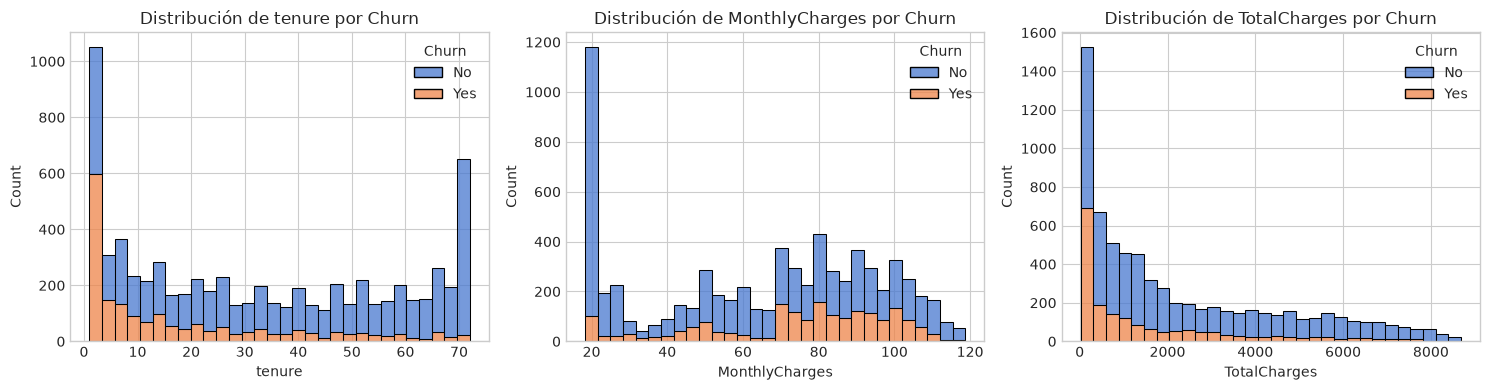

In [8]:
# Distribuciones de variables numéricas por Churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, hue='Churn', multiple='stack', ax=ax, bins=30)
    ax.set_title(f'Distribución de {col} por Churn')

plt.tight_layout()
plt.show()


tenure (antigüedad): la mayor concentración de churn (naranja) está en los primeros meses (barra alta cerca de 0). A medida que avanza la antigüedad, la proporción de naranja disminuye notoriamente.Los clientes nuevos son mucho más propensos a irse que los clientes antiguos.

MonthlyCharges — el patrón es casi inverso: el churn (naranja) es proporcionalmente más alto en cargos mensuales elevados (70-100+), mientras que en cargos bajos (cerca de 20) casi todo es azul (no-churn). Esto concluye que clientes que pagan más tienden a irse más — quizás sienten que no reciben suficiente valor por ese precio, o son más sensibles a comparar con la competencia.

TotalCharges — el churn se concentra fuertemente en valores bajos (cerca de 0-1000). Esto tiene sentido y es consistente con tenure: como TotalCharges se acumula con el tiempo, los clientes que se van rápido (poco tenure) naturalmente tienen poco TotalCharges acumulado — es casi la misma señal vista desde otro ángulo.

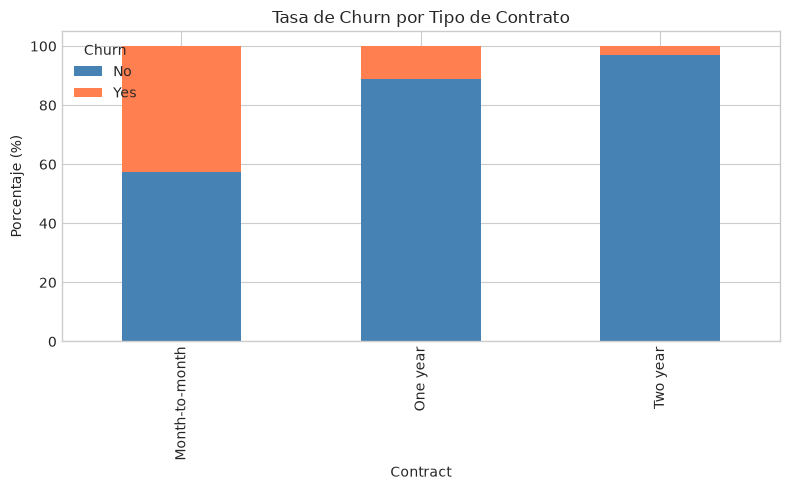

In [9]:
# Churn según tipo de contrato
fig, ax = plt.subplots(figsize=(8, 5))
churn_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
churn_contract.plot(kind='bar', stacked=True, ax=ax, color=['steelblue', 'coral'])
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Tasa de Churn por Tipo de Contrato')
ax.legend(title='Churn')
plt.tight_layout()
plt.show()

Los clientes con contrato mes a mes tienen una probabilidad de fuga más de 10 veces mayor que los clientes con contrato de dos años. Esto tiene una lógica de negocio perfectamente clara: un contrato mes a mes no tiene "costo de salida". El cliente puede irse cuando quiera sin penalización, mientras que un contrato de 1-2 años genera un compromiso (y posiblemente beneficios/descuentos) que retiene al cliente.

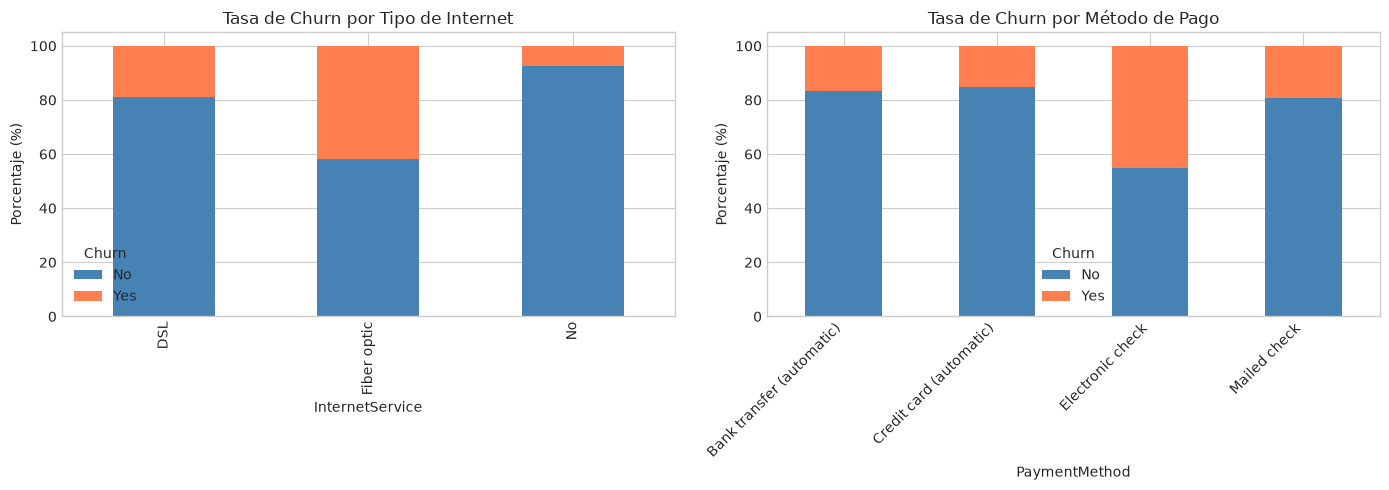

In [10]:
# Churn según tipo de servicio de internet y método de pago
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_internet = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
churn_internet.plot(kind='bar', stacked=True, ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_title('Tasa de Churn por Tipo de Internet')
axes[0].legend(title='Churn')

churn_payment = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
churn_payment.plot(kind='bar', stacked=True, ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Tasa de Churn por Método de Pago')
axes[1].legend(title='Churn')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

2. Preprocesar los datos, incluyendo la limpieza, la transformación y la normalización de las características según sea necesario

In [11]:
# Eliminar customerID (no aporta valor predictivo)
df_model = df.drop(columns=['customerID'])

# Convertir la variable objetivo Churn a binaria (0/1)
df_model['Churn'] = df_model['Churn'].map({'No': 0, 'Yes': 1})

print(df_model['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [12]:
# Identificar columnas categóricas (texto) a codificar
columnas_categoricas = df_model.select_dtypes(include='object').columns.tolist()
print('Columnas categóricas a codificar:')
print(columnas_categoricas)

Columnas categóricas a codificar:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/tmp/ipykernel_1661/4144992961.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df_model.select_dtypes(include='object').columns.tolist()


In [13]:
# One-Hot Encoding de las variables categóricas
df_model = pd.get_dummies(df_model, columns=columnas_categoricas, drop_first=True)

print(f'Dimensiones después de codificar: {df_model.shape}')
df_model.head()

Dimensiones después de codificar: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [14]:
from sklearn.preprocessing import StandardScaler

# Separar features y variable objetivo
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Identificar variables numéricas continuas a escalar
columnas_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Estandarizar
scaler = StandardScaler()
X[columnas_numericas] = scaler.fit_transform(X[columnas_numericas])

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.280248,-1.161694,-0.994194,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,0.064303,-0.260878,-0.173740,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,-1.239504,-0.363923,-0.959649,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,0.512486,-0.747850,-0.195248,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,-1.239504,0.196178,-0.940457,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


3. Dividir los datos en conjuntos de entrenamiento y prueba.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} clientes')
print(f'Prueba: {X_test.shape[0]} clientes')
print()
print('Proporción de Churn en train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Proporción de Churn en test:', y_test.value_counts(normalize=True).round(3).to_dict())

Entrenamiento: 5625 clientes
Prueba: 1407 clientes

Proporción de Churn en train: {0: 0.734, 1: 0.266}
Proporción de Churn en test: {0: 0.734, 1: 0.266}


stratify=y Le dice a la función que mantenga la misma proporción de Churn (73.4%/26.6%) tanto en train como en test. Sin esto, por simple azar podrías terminar con, por ejemplo, 30% de churn en train y solo 18% en test — lo cual distorsionaría la evaluación. Con datasets desbalanceados como este, stratify es una buena práctica casi obligatoria

4. Entrenar al menos 3 algoritmos y optimizar sus hiperparametros

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# GridSearchCV para Árbol de Decisión
params_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), params_tree, cv=5, scoring='f1')
grid_tree.fit(X_train, y_train)

print('Mejores hiperparámetros (Árbol):', grid_tree.best_params_)
print('Mejor F1 Score en CV:', round(grid_tree.best_score_, 3))

Mejores hiperparámetros (Árbol): {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor F1 Score en CV: 0.585


In [17]:
from sklearn.neighbors import KNeighborsClassifier

# GridSearchCV para KNN
params_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), params_knn, cv=5, scoring='f1')
grid_knn.fit(X_train, y_train)

print('Mejores hiperparámetros (KNN):', grid_knn.best_params_)
print('Mejor F1 Score en CV:', round(grid_knn.best_score_, 3))

Mejores hiperparámetros (KNN): {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'uniform'}
Mejor F1 Score en CV: 0.588


In [18]:
from sklearn.linear_model import LogisticRegression

# GridSearchCV para Regresión Logística
params_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_logreg = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), params_logreg, cv=5, scoring='f1')
grid_logreg.fit(X_train, y_train)

print('Mejores hiperparámetros (Regresión Logística):', grid_logreg.best_params_)
print('Mejor F1 Score en CV:', round(grid_logreg.best_score_, 3))

/home/thinkbook/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/thinkbook/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/thinkbook/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of p

Mejores hiperparámetros (Regresión Logística): {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor F1 Score en CV: 0.597


5. Evaluar el rendimiento de los modelos utilizando métricas de evaluación pertinentes, como precisión, sensibilidad, valor F1, entre otras.

In [20]:
from sklearn.metrics import classification_report

# Predicciones en test para los 3 modelos optimizados
y_pred_tree = grid_tree.predict(X_test)
y_pred_knn = grid_knn.predict(X_test)
y_pred_logreg = grid_logreg.predict(X_test)

print('=== Árbol de Decisión ===')
print(classification_report(y_test, y_pred_tree))

print('=== KNN ===')
print(classification_report(y_test, y_pred_knn))

print('=== Regresión Logística ===')
print(classification_report(y_test, y_pred_logreg))

=== Árbol de Decisión ===
              precision    recall  f1-score   support

           0       0.85      0.80      0.83      1033
           1       0.53      0.61      0.57       374

    accuracy                           0.75      1407
   macro avg       0.69      0.71      0.70      1407
weighted avg       0.77      0.75      0.76      1407

=== KNN ===
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1033
           1       0.60      0.58      0.59       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.72      1407
weighted avg       0.78      0.79      0.79      1407

=== Regresión Logística ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted

Regresión Logística gana en Accuracy global (0.80), Precision de clase 1 (0.65) y F1 de clase 1 (0.61) — consistente con lo que ya habíamos visto en Cross-Validation.
Pero el Árbol de Decisión tiene el mejor Recall de clase 1 (0.61) — es el que detecta más clientes que realmente se van, aunque a costa de más falsas alarmas (su Precision de 0.53 es la más baja de los tres).
KNN queda en un punto intermedio en casi todas las métricas, sin destacar particularmente en ninguna.

¿Qué error es más costoso para FreshMart?  perder a un cliente sin detectarlo (falso negativo, afecta Recall) o gastar recursos en retener a alguien que de todas formas no se iba a ir (falso positivo, afecta Precision)?

En la mayoría de los negocios de retención de clientes, el costo de no detectar a tiempo a un cliente que se va es mayor que el costo de una llamada de retención "de más" por lo que Recall suele ser la métrica prioritaria en problemas de churn. Bajo ese criterio, el Árbol de Decisión sería la elección más defendible, a pesar de tener el F1 y Accuracy más bajos de los tres.